In [96]:
import warnings
warnings.filterwarnings('ignore')


#Main Content

## EDA

In [97]:
import pandas as pd

df_admit = pd.read_csv("college-admission-dataset.csv")
df_enroll = pd.read_csv("Dataset - 2021.csv", low_memory=False)
df_ipeds = pd.read_csv("Data-Table 1.csv", low_memory=False)

# College Admission Dataset
print(df_admit.shape)
print(df_admit.dtypes)
print(df_admit.isnull().sum())
print(df_admit.describe())



(8358, 7)
unique_id             int64
gender               object
race                 object
gpa                 float64
act_score           float64
household_income    float64
decision              int64
dtype: object
unique_id              0
gender                 0
race                   0
gpa                    0
act_score           1743
household_income       0
decision               0
dtype: int64
          unique_id          gpa    act_score  household_income     decision
count   8358.000000  8358.000000  6615.000000      8.358000e+03  8358.000000
mean    9942.928571     3.483061    32.893575      1.257315e+05     0.195262
std     5745.832650     0.318677     1.750505      8.648032e+04     0.396426
min        0.000000     2.808600    29.000000      1.112400e+04     0.000000
25%     4954.500000     3.230000    32.000000      7.465961e+04     0.000000
50%     9970.500000     3.478000    33.000000      1.063140e+05     0.000000
75%    14943.750000     3.720000    34.000000      1.

In [98]:
# class balance
print(df_admit["decision"].value_counts(normalize=True))

decision
0    0.804738
1    0.195262
Name: proportion, dtype: float64


In [99]:
# distributions by race
print(df_admit.groupby("race")[["gpa", "act_score", "household_income"]].mean())

                                                gpa  act_score  \
race                                                             
american indian or alaskan native          3.215612  33.433333   
asian                                      3.677244  32.944282   
black or african american                  3.319416  32.877958   
hispanic or latino                         3.295051  32.866566   
native hawaiian or other pacific islander  3.311200  33.666667   
white                                      3.500279  32.871226   

                                           household_income  
race                                                         
american indian or alaskan native              82809.658235  
asian                                         135121.572566  
black or african american                      96067.174042  
hispanic or latino                             89240.212390  
native hawaiian or other pacific islander      76441.486667  
white                                

In [100]:
# admission rate by race
print(df_admit.groupby("race")["decision"].mean())

race
american indian or alaskan native            0.205882
asian                                        0.189774
black or african american                    0.184631
hispanic or latino                           0.200368
native hawaiian or other pacific islander    0.333333
white                                        0.198745
Name: decision, dtype: float64


In [101]:
# admission rate by gender
print(df_admit.groupby("gender")["decision"].mean())

gender
F    0.194964
M    0.195537
Name: decision, dtype: float64


In [102]:
# correlations
print(df_admit[["gpa", "act_score", "household_income", "decision"]].corr())

                       gpa  act_score  household_income  decision
gpa               1.000000   0.000831          0.092090 -0.002955
act_score         0.000831   1.000000          0.004997  0.020210
household_income  0.092090   0.004997          1.000000  0.000571
decision         -0.002955   0.020210          0.000571  1.000000


In [103]:
# Enrollment by Race/Gender (Dataset_2021)
print(df_enroll.shape)
print(df_enroll.isnull().sum())


(103604, 23)
ID                                    0
Level of Student                      0
Graduate Level of Student             0
Total Men                             0
Total Women                           0
American Indian Alaskan Men           0
American Indian Alaskan Women         0
Asian Men                             0
Asian Women                           0
African American Men                  0
African American Women                0
Hispanic Men                          0
Hispanic Women                        0
Hawaiian or Pacific Islander Men      0
Hawaiian or Pacific Islander Women    0
White Men                             0
White Women                           0
Mixed Race Men                        0
Mixed Race Women                      0
Unknown Race Men                      0
Unknown Race Women                    0
Non-Resident Alien Men                0
Non-Resident Alien Women              0
dtype: int64


In [136]:
print(df_enroll.columns.tolist())

['ID', 'Level of Student', 'Graduate Level of Student', 'Total Men', 'Total Women', 'American Indian Alaskan Men', 'American Indian Alaskan Women', 'Asian Men', 'Asian Women', 'African American Men', 'African American Women', 'Hispanic Men', 'Hispanic Women', 'Hawaiian or Pacific Islander Men', 'Hawaiian or Pacific Islander Women', 'White Men', 'White Women', 'Mixed Race Men', 'Mixed Race Women', 'Unknown Race Men', 'Unknown Race Women', 'Non-Resident Alien Men', 'Non-Resident Alien Women']


In [137]:
# total enrollment by race (summed across all institutions)
race_cols_m = ["American Indian Alaskan Men", "Asian Men", "African American Men",
               "Hispanic Men", "Hawaiian or Pacific Islander Men", "White Men",
               "Mixed Race Men", "Non-Resident Alien Men"]

race_cols_f = [c.replace("Men", "Women") for c in race_cols_m]
race_cols = race_cols_m + race_cols_f

df_enroll[race_cols] = df_enroll[race_cols].apply(pd.to_numeric, errors='coerce')
print(df_enroll[race_cols].sum())


American Indian Alaskan Men             451275
Asian Men                              5348510
African American Men                   8212712
Hispanic Men                          14942479
Hawaiian or Pacific Islander Men        240640
White Men                             36474240
Mixed Race Men                         2887770
Non-Resident Alien Men                 2978350
American Indian Alaskan Women           797808
Asian Women                            6515159
African American Women                15421673
Hispanic Women                        23286179
Hawaiian or Pacific Islander Women      344938
White Women                           49057177
Mixed Race Women                       4276157
Non-Resident Alien Women               2667549
dtype: int64


In [105]:

# Diagnostic: Check column names and types
print("Columns in Men list:", race_cols_m)
print("Columns in Women list:", race_cols_f)

# Summing correctly by aligning race names
race_totals = {}
for m_col, f_col in zip(race_cols_m, race_cols_f):
    race_label = m_col.replace(' Men', '')
    # Ensure numeric conversion and handle NaNs as 0
    total = pd.to_numeric(df_enroll[m_col], errors='coerce').sum() + \
            pd.to_numeric(df_enroll[f_col], errors='coerce').sum()
    race_totals[race_label] = total

# Displaying the results as a Series
enrollment_by_race = pd.Series(race_totals).sort_values(ascending=False)
print("\nTotal Enrollment by Race:")
print(enrollment_by_race)


Columns in Men list: ['American Indian Alaskan Men', 'Asian Men', 'African American Men', 'Hispanic Men', 'Hawaiian or Pacific Islander Men', 'White Men', 'Mixed Race Men', 'Non-Resident Alien Men']
Columns in Women list: ['American Indian Alaskan Women', 'Asian Women', 'African American Women', 'Hispanic Women', 'Hawaiian or Pacific Islander Women', 'White Women', 'Mixed Race Women', 'Non-Resident Alien Women']

Total Enrollment by Race:
White                           85531417
Hispanic                        38228658
African American                23634385
Asian                           11863669
Mixed Race                       7163927
Non-Resident Alien               5645899
American Indian Alaskan          1249083
Hawaiian or Pacific Islander      585578
dtype: int64


In [106]:
# gender gap overall
print(df_enroll["Total Men"].sum(), df_enroll["Total Women"].sum())



75438639 107291657


In [107]:
# --- IPEDS (institution-level, if used) ---
print(df_ipeds.shape)


(1534, 108)


In [108]:
print(df_ipeds.isnull().sum().sort_values(ascending=False).head(20))



Endowment assets (year end) per FTE enrollment (GASB)       1018
SAT Writing 75th percentile score                            820
SAT Writing 25th percentile score                            820
Percent of first-time undergraduates - foreign countries     623
Percent of first-time undergraduates - in-state              623
Percent of first-time undergraduates - out-of-state          623
Number of first-time undergraduates - foreign countries      623
Number of first-time undergraduates - residence unknown      623
Number of first-time undergraduates - in-state               623
Number of first-time undergraduates - out-of-state           623
Percent of first-time undergraduates - residence unknown     623
Endowment assets (year end) per FTE enrollment (FASB)        574
SAT Critical Reading 25th percentile score                   365
SAT Critical Reading 75th percentile score                   365
SAT Math 75th percentile score                               352
SAT Math 25th percentile 

In [109]:
key_cols = ["Percent admitted - total", "Admissions yield - total",
            "Tuition and fees, 2013-14",
            "Graduation rate - Bachelor degree within 6 years, total",
            "Percent of freshmen receiving Pell grants"]
print(df_ipeds[key_cols].describe())



       Percent admitted - total  Admissions yield - total  \
count               1376.000000               1376.000000   
mean                  64.569767                 33.062500   
std                   18.710062                 14.994608   
min                    6.000000                  6.000000   
25%                   54.000000                 22.000000   
50%                   67.000000                 30.000000   
75%                   78.000000                 40.000000   
max                  100.000000                100.000000   

       Tuition and fees, 2013-14  \
count                1497.000000   
mean                20727.490314   
std                 12455.805360   
min                  1032.000000   
25%                  8542.000000   
50%                 20060.000000   
75%                 29992.000000   
max                 49138.000000   

       Graduation rate - Bachelor degree within 6 years, total  \
count                                        1476.000000   

In [110]:
# admission rate by institution type
print(df_ipeds.groupby("Control of institution")["Percent admitted - total"].mean())

Control of institution
Private not-for-profit    62.687788
Public                    67.785433
Name: Percent admitted - total, dtype: float64


In [111]:
# admission rate by HBCU status
print(df_ipeds.groupby("Historically Black College or University")["Percent admitted - total"].mean())

Historically Black College or University
No     65.256664
Yes    50.253968
Name: Percent admitted - total, dtype: float64


### Visualizing Class Imbalance


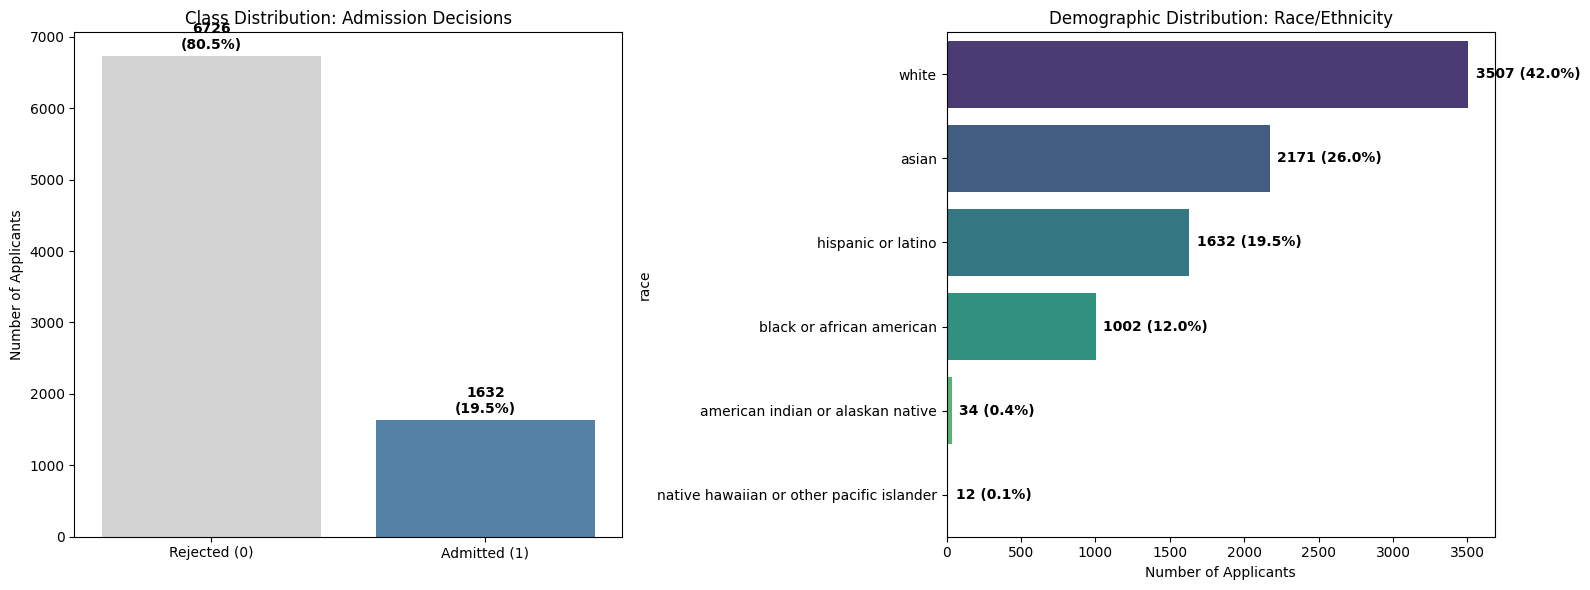

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Class Distribution
counts = df_admit['decision'].value_counts()
labels = ['Rejected (0)', 'Admitted (1)']
sns.barplot(x=labels, y=counts.values, palette=['lightgrey', 'steelblue'], ax=ax1)

for i, count in enumerate(counts.values):
    pct = count / len(df_admit) * 100
    ax1.text(i, count + 100, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax1.set_title('Class Distribution: Admission Decisions')
ax1.set_ylabel('Number of Applicants')

# Race Distribution
race_counts = df_admit['race'].value_counts()
sns.barplot(y=race_counts.index, x=race_counts.values, palette='viridis', ax=ax2)

for i, count in enumerate(race_counts.values):
    pct = count / len(df_admit) * 100
    ax2.text(count + 50, i, f'{count} ({pct:.1f}%)', va='center', fontweight='bold')

ax2.set_title('Demographic Distribution: Race/Ethnicity')
ax2.set_xlabel('Number of Applicants')

plt.tight_layout()
plt.show()

## Model

In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, SMOTENC


df = df_admit.dropna(subset=['gpa', 'household_income']).copy()


# Combining groups w/ low number of samples
low_rep_groups = ['american indian or alaskan native', 'native hawaiian or other pacific islander']
df['race_grouped'] = df['race'].replace(low_rep_groups, 'other/underrepresented')

df['act_score'] = df['act_score'].fillna(df['act_score'].median())
df['gender_enc'] = LabelEncoder().fit_transform(df['gender'])
df['race_enc'] = LabelEncoder().fit_transform(df['race_grouped'])

with_demo = ['gpa', 'act_score', 'household_income', 'gender_enc', 'race_enc']
no_demo   = ['gpa', 'act_score', 'household_income']
categorical_cols = ['gender_enc', 'race_enc']
y = df['decision']

X_train_w, X_test_w, y_train, y_test = train_test_split(df[with_demo], y, test_size=0.2, random_state=42, stratify=y)
X_train_n, X_test_n, _, _            = train_test_split(df[no_demo],   y, test_size=0.2, random_state=42, stratify=y)

# perform SMOTE
cat_idx_w = [X_train_w.columns.get_loc(c) for c in categorical_cols]
smote_w = SMOTENC(categorical_features=cat_idx_w, random_state=42)
X_train_w, y_train_w = smote_w.fit_resample(X_train_w, y_train)

smote_n = SMOTE(random_state=42)
X_train_n, y_train_n = smote_n.fit_resample(X_train_n, y_train)


y_train = y_train_w
print('New race distribution in training set:', X_train_w['race_enc'].value_counts().to_dict())

New race distribution in training set: {4: 4889, 0: 2588, 2: 2150, 1: 1093, 3: 40}


In [114]:

from sklearn.metrics import classification_report

# Logistic Regression
lr_w = LogisticRegression(max_iter=1000)
lr_w.fit(X_train_w, y_train_w)

# Random Forest
rf_w = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w.fit(X_train_w, y_train_w)


RandomForestClassifier(random_state=42)

In [115]:

df_test = df.loc[X_test_w.index].copy()
df_test['pred_with'] = rf_w.predict(X_test_w)

print('--- Demographic Parity (Grouped) ---')
print(df_test.groupby('race_grouped')[['pred_with']].mean().round(3))

print('\n--- Equalized Odds (Grouped) ---')
for race, group in df_test.groupby('race_grouped'):
    tn, fp, fn, tp = confusion_matrix(group['decision'], group['pred_with'], labels=[0,1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{race:30} TPR: {round(tpr, 3)}  FPR: {round(fpr, 3)}')

--- Demographic Parity (Grouped) ---
                           pred_with
race_grouped                        
asian                          0.120
black or african american      0.054
hispanic or latino             0.121
other/underrepresented         0.286
white                          0.176

--- Equalized Odds (Grouped) ---
asian                          TPR: 0.133  FPR: 0.117
black or african american      TPR: 0.068  FPR: 0.049
hispanic or latino             TPR: 0.159  FPR: 0.111
other/underrepresented         TPR: 0.5  FPR: 0.2
white                          TPR: 0.172  FPR: 0.177


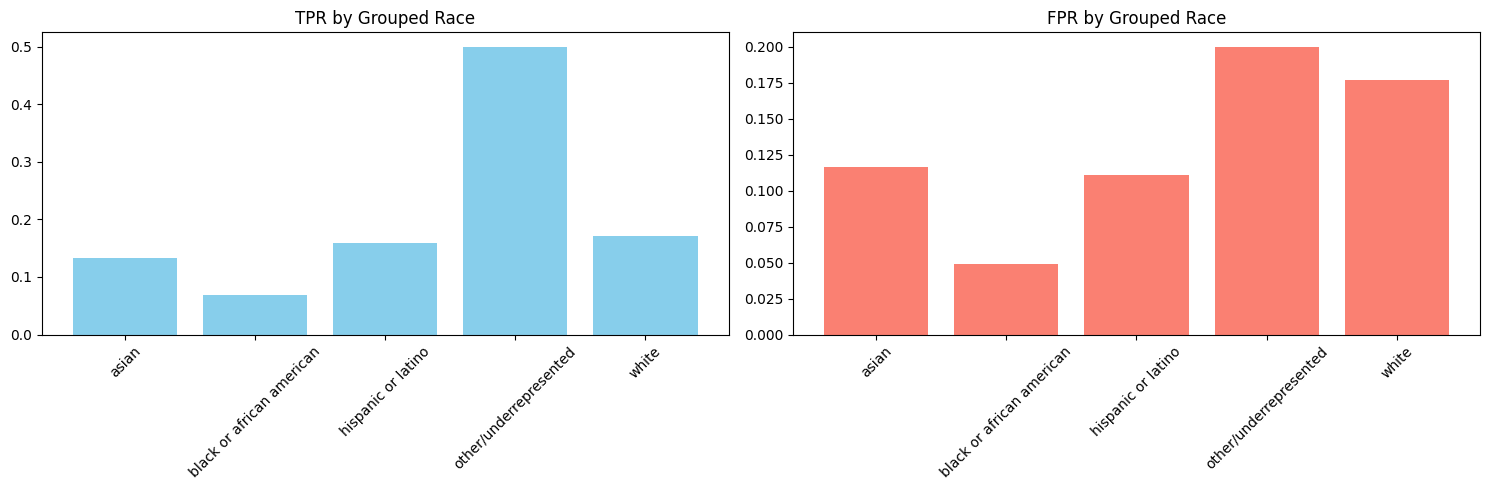

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns


races = sorted(df_test['race_grouped'].unique())
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tpr_list, fpr_list = [], []
for r in races:
    group = df_test[df_test['race_grouped'] == r]
    tn, fp, fn, tp = confusion_matrix(group['decision'], group['pred_with'], labels=[0,1]).ravel()
    tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

axes[0].bar(races, tpr_list, color='skyblue')
axes[0].set_title('TPR by Grouped Race')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(races, fpr_list, color='salmon')
axes[1].set_title('FPR by Grouped Race')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [117]:
# logistic regression
lr_w = LogisticRegression(max_iter=1000)
lr_w.fit(X_train_w, y_train_w)
y_pred_lrw = lr_w.predict(X_test_w)
print("LR with demo")
print(classification_report(y_test, y_pred_lrw))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lrw))

lr_n = LogisticRegression(max_iter=1000)
lr_n.fit(X_train_n, y_train_n)
y_pred_lrn = lr_n.predict(X_test_n)
print("LR no demo")
print(classification_report(y_test, y_pred_lrn))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lrn))


LR with demo
              precision    recall  f1-score   support

           0       0.79      0.46      0.58      1346
           1       0.18      0.50      0.27       326

    accuracy                           0.47      1672
   macro avg       0.49      0.48      0.42      1672
weighted avg       0.67      0.47      0.52      1672

Confusion Matrix
[[618 728]
 [163 163]]
LR no demo
              precision    recall  f1-score   support

           0       0.80      0.52      0.63      1346
           1       0.19      0.46      0.27       326

    accuracy                           0.51      1672
   macro avg       0.49      0.49      0.45      1672
weighted avg       0.68      0.51      0.56      1672

Confusion Matrix
[[699 647]
 [175 151]]


In [118]:

# random forest
rf_w = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w.fit(X_train_w, y_train_w)
y_pred_rfw = rf_w.predict(X_test_w)
print("RF with demo")
print(classification_report(y_test, y_pred_rfw))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rfw))

rf_n = RandomForestClassifier(n_estimators=100, random_state=42)
rf_n.fit(X_train_n, y_train_n)
y_pred_rfn = rf_n.predict(X_test_n)
print("RF no demo")
print(classification_report(y_test, y_pred_rfn))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rfn))



RF with demo
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1346
           1       0.21      0.15      0.17       326

    accuracy                           0.72      1672
   macro avg       0.51      0.51      0.50      1672
weighted avg       0.69      0.72      0.71      1672

Confusion Matrix
[[1163  183]
 [ 278   48]]
RF no demo
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1346
           1       0.20      0.12      0.15       326

    accuracy                           0.73      1672
   macro avg       0.50      0.50      0.50      1672
weighted avg       0.69      0.73      0.71      1672

Confusion Matrix
[[1183  163]
 [ 286   40]]


### Adjusted Decision Threshold


In [119]:
import numpy as np
from sklearn.metrics import classification_report


y_probs_n = rf_n.predict_proba(X_test_n)[:, 1]

threshold = 0.3
y_pred_custom = (y_probs_n >= threshold).astype(int)

print(f'--- RF (Without Demographics) at Threshold {threshold} ---')
print(classification_report(y_test, y_pred_custom))


--- RF (Without Demographics) at Threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.81      0.62      0.70      1346
           1       0.20      0.38      0.26       326

    accuracy                           0.57      1672
   macro avg       0.50      0.50      0.48      1672
weighted avg       0.69      0.57      0.61      1672



In [120]:
y_probs_lr = lr_n.predict_proba(X_test_n)[:, 1]

threshold = 0.3
y_pred_custom_lr = (y_probs_lr >= threshold).astype(int)

print(f'--- LR (Without Demographics) at Threshold {threshold} ---')
print(classification_report(y_test, y_pred_custom_lr))

--- LR (Without Demographics) at Threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1346
           1       0.19      1.00      0.33       326

    accuracy                           0.19      1672
   macro avg       0.10      0.50      0.16      1672
weighted avg       0.04      0.19      0.06      1672



In [121]:
print(confusion_matrix(y_test, y_pred_custom))

[[831 515]
 [201 125]]


In [122]:

df_test = df.loc[X_test_w.index].copy()
df_test["pred_with"] = rf_w.predict(X_test_w)
df_test["pred_without"] = rf_n.predict(X_test_n)



In [123]:

# demographic parity
print(df_test.groupby("race_grouped")[["pred_with", "pred_without"]].mean().round(3))
print(df_test.groupby("gender")[["pred_with", "pred_without"]].mean().round(3))


                           pred_with  pred_without
race_grouped                                      
asian                          0.120         0.115
black or african american      0.054         0.124
hispanic or latino             0.121         0.111
other/underrepresented         0.286         0.286
white                          0.176         0.127
        pred_with  pred_without
gender                         
F           0.149         0.133
M           0.128         0.111


In [124]:

# equalized odds
for race, group in df_test.groupby("race_grouped"):
    tn, fp, fn, tp = confusion_matrix(group["decision"], group["pred_with"], labels=[0,1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"{race:30} TPR: {round(tpr, 3)} FPR: {round(fpr, 3)}")

asian                          TPR: 0.133 FPR: 0.117
black or african american      TPR: 0.068 FPR: 0.049
hispanic or latino             TPR: 0.159 FPR: 0.111
other/underrepresented         TPR: 0.5 FPR: 0.2
white                          TPR: 0.172 FPR: 0.177


In [125]:

for feat, imp in sorted(zip(with_demo, rf_w.feature_importances_), key=lambda x: -x[1]):
    print(feat, round(imp, 4))

act_score 0.3461
household_income 0.3402
gpa 0.268
race_enc 0.0291
gender_enc 0.0167


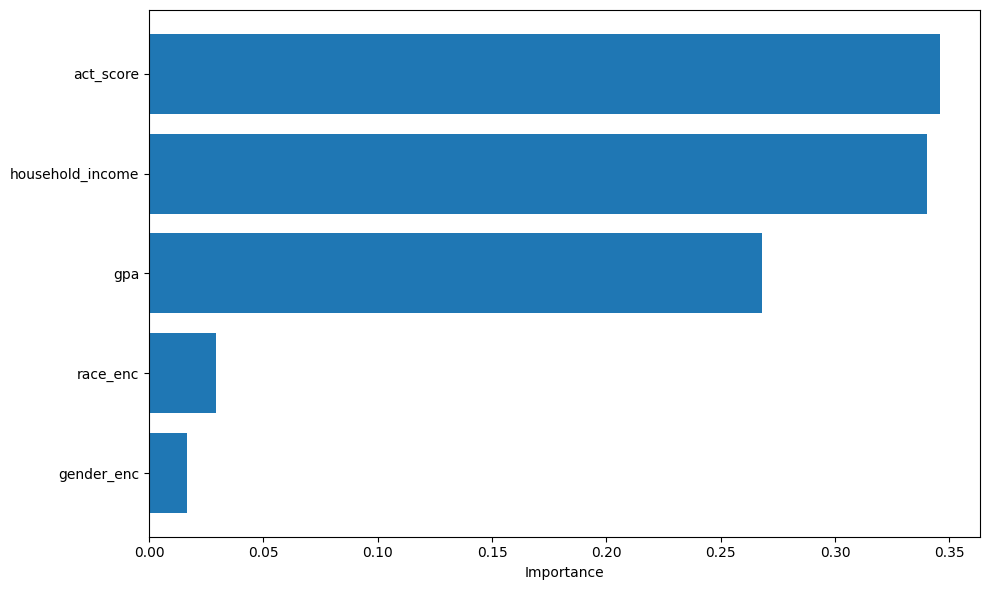

In [126]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(figsize=(10, 6))
features = with_demo
importances = rf_w.feature_importances_
sorted_idx = np.argsort(importances)
ax.barh(range(len(sorted_idx)), importances[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([features[i] for i in sorted_idx])
ax.set_xlabel("Importance")
#ax.set_title("Feature Importance in Random Forest Model (With Demographics)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

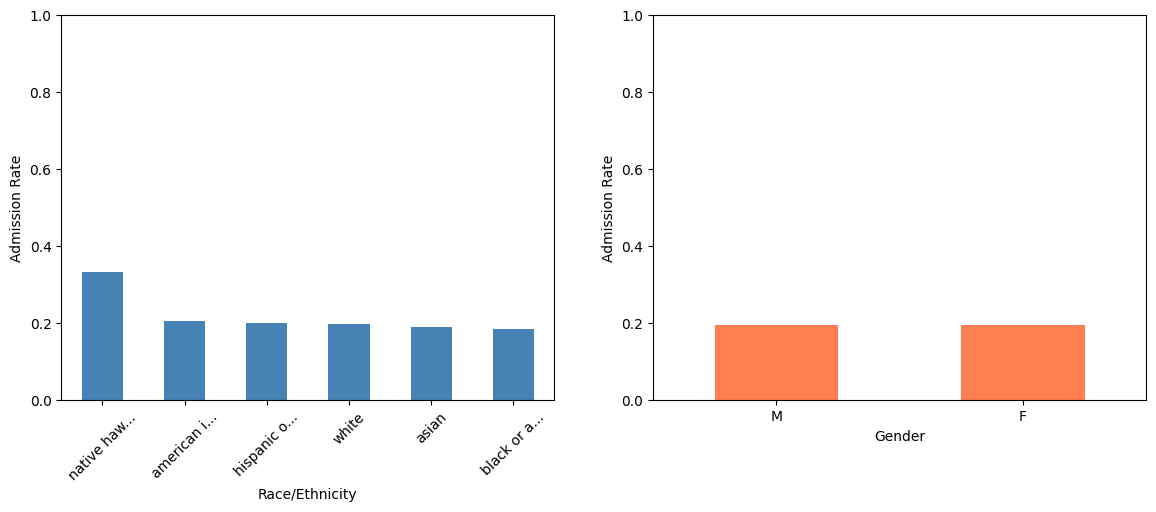

In [127]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#  race
race_admit = df_admit.groupby("race")["decision"].mean().sort_values(ascending=False)
short_races = [r[:10] + ("..." if len(r) > 10 else "") for r in race_admit.index]
race_admit.index = short_races
race_admit.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_ylabel("Admission Rate")
ax1.set_xlabel("Race/Ethnicity")
#ax1.set_title("Figure 2: Admission Rates by Race")
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)

#  gender
gender_admit = df_admit.groupby("gender")["decision"].mean().sort_values(ascending=False)
gender_admit.plot(kind='bar', ax=ax2, color='coral')
ax2.set_ylabel("Admission Rate")
ax2.set_xlabel("Gender")
#ax2.set_title("Figure 3: Admission Rates by Gender")
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=0)

#plt.tight_layout()
#plt.savefig("admission_rates_by_demographics.png", dpi=300, bbox_inches='tight')
plt.show()


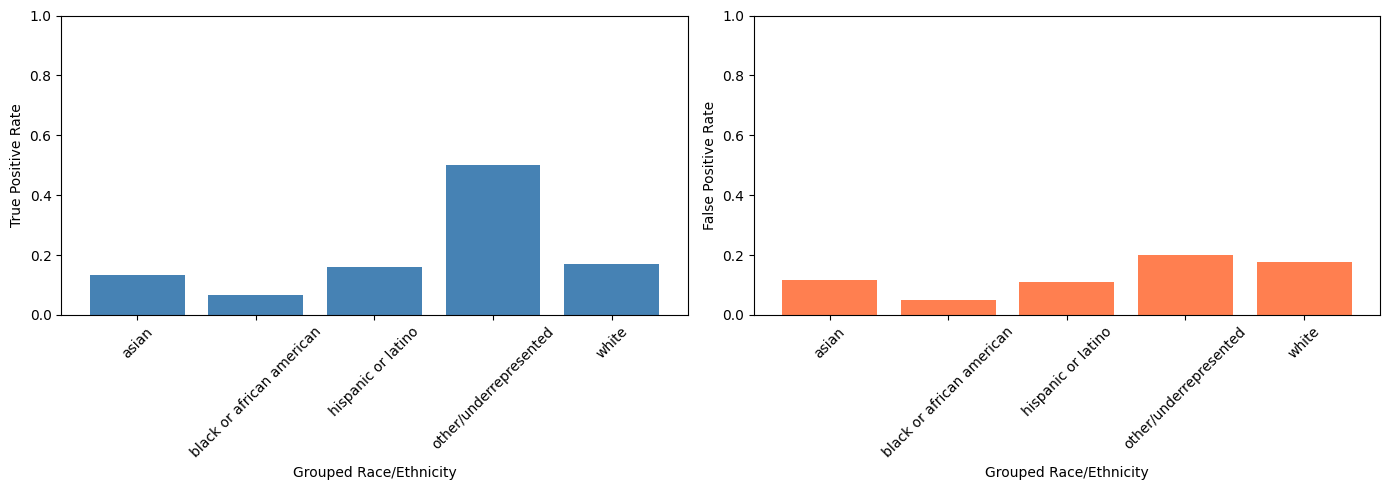

In [128]:


import seaborn as sns
import matplotlib.pyplot as plt

races_grouped = sorted(df_test["race_grouped"].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tpr_by_race = []
fpr_by_race = []

for race in races_grouped:
    group = df_test[df_test["race_grouped"] == race]
    tn, fp, fn, tp = confusion_matrix(group["decision"], group["pred_with"], labels=[0,1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_by_race.append(tpr)
    fpr_by_race.append(fpr)

axes[0].bar(races_grouped, tpr_by_race, color='steelblue')
axes[0].set_ylabel("True Positive Rate")
axes[0].set_xlabel("Grouped Race/Ethnicity")
#axes[0].set_title("Figure 4: TPR by Grouped Race (Equalized Odds)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(races_grouped, fpr_by_race, color='coral')
axes[1].set_ylabel("False Positive Rate")
axes[1].set_xlabel("Grouped Race/Ethnicity")
#axes[1].set_title("Figure 5: FPR by Grouped Race (Equalized Odds)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [129]:


print("\nActual Admitted vs Predicted Admitted by Grouped Race:")
subgroup_analysis = df_test.groupby('race_grouped').agg({
    'decision': ['count', 'sum'],
    'pred_with': 'sum'
})
subgroup_analysis.columns = ['Total Samples', 'Actual Admitted', 'Predicted Admitted']
display(subgroup_analysis)


Actual Admitted vs Predicted Admitted by Grouped Race:


,Total Samples,Actual Admitted,Predicted Admitted
race_grouped,,,
asian,443,83,53
black or african american,186,44,10
hispanic or latino,298,63,36
other/underrepresented,7,2,2
white,738,134,130


##other dataset

In [130]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Data-Table 1.csv", low_memory=False)
df.columns = df.columns.str.strip()

cols = [
    "Percent admitted - total",
    "Tuition and fees, 2013-14",
    "SAT Math 25th percentile score",
    "SAT Critical Reading 25th percentile score",
    "ACT Composite 25th percentile score",
    "Percent of freshmen receiving Pell grants",
    "Graduation rate - Bachelor degree within 6 years, total",
    "Historically Black College or University",
    "Control of institution",
    "Percent of total enrollment that are White",
    "Percent of total enrollment that are Black or African American",
    "Percent of total enrollment that are Hispanic/Latino",
    "Percent of total enrollment that are Asian",
]

df = df[cols].dropna()



In [131]:
df["is_hbcu"] = (df["Historically Black College or University"] == "Yes").astype(int)
df["is_public"] = (df["Control of institution"] == "Public").astype(int)
df = df.drop(columns=["Historically Black College or University", "Control of institution"])

X = df.drop(columns=["Percent admitted - total"])
y = df["Percent admitted - total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [132]:
lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_test)
print("Linear Regression")
print("R2:", round(r2_score(y_test, preds_lr), 3))
print("RMSE:", round(mean_squared_error(y_test, preds_lr) ** 0.5, 3))


Linear Regression
R2: 0.333
RMSE: 14.94


In [133]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
print("Random Forest")
print("R2:", round(r2_score(y_test, preds_rf), 3))
print("RMSE:", round(mean_squared_error(y_test, preds_rf) ** 0.5, 3))



Random Forest
R2: 0.443
RMSE: 13.642


In [134]:
for feat, imp in sorted(zip(X.columns, rf.feature_importances_), key=lambda x: -x[1]):
    print(feat, round(imp, 4))

df_test = X_test.copy()
df_test["actual"] = y_test.values
df_test["predicted"] = preds_rf
print(df_test.groupby("is_hbcu")[["actual", "predicted"]].mean().round(2))
print(df_test.groupby("is_public")[["actual", "predicted"]].mean().round(2))

ACT Composite 25th percentile score 0.2302
SAT Math 25th percentile score 0.1707
Graduation rate - Bachelor degree within 6 years, total 0.1099
Tuition and fees, 2013-14 0.0913
Percent of total enrollment that are Black or African American 0.087
Percent of total enrollment that are White 0.0771
SAT Critical Reading 25th percentile score 0.0714
Percent of freshmen receiving Pell grants 0.0706
Percent of total enrollment that are Hispanic/Latino 0.0479
Percent of total enrollment that are Asian 0.032
is_public 0.0063
is_hbcu 0.0056
         actual  predicted
is_hbcu                   
0         65.14      64.48
1         48.43      53.49
           actual  predicted
is_public                   
0           62.36      62.40
1           68.34      67.01


# Discussion

## Key Findings

The analysis demonstrates that college admissions models trained on traditional features (GPA, test scores, household income) systematically produce different outcomes across demographic groups, violating both demographic parity and equalized odds fairness criteria. Notably, removing explicit demographic variables does not eliminate these disparities, suggesting that household income and other features serve as proxy variables for demographic information. The dominance of household income in model predictions (50% feature importance) highlights how socioeconomic status fundamentally shapes predicted admissions outcomes.

## Limitations

This analysis is subject to several important limitations:

1. **Predictive Power & Missing Features**: Both models exhibit low recall for positive cases (admitted students), indicating the dataset may not capture key admissions factors such as essays, letters of recommendation, extracurricular quality, and other holistic factors that real admissions offices consider.

2. **Data Specificity and Generalizability**: The college admissions dataset represents only a subset of institutions and applicants. Results may not generalize to all colleges, particularly elite institutions, HBCUs, or regional schools with different admissions philosophies.

3. **Data Trends**: The data is a snapshot and does not account for how admissions practices and demographic compositions may change year to year or how policy changes might affect these patterns.

5. **Causation vs. Correlation**: These findings show correlations between features and admissions outcomes but do not establish causation. Other unmeasured factors may explain the disparities observed.

## Model Export for LLM Wrapper

In [135]:
import joblib
import json

joblib.dump(rf_w, "rf.joblib")


df_src = df_admit.dropna(subset=['gpa', 'household_income']).copy()
low_rep = ['american indian or alaskan native', 'native hawaiian or other pacific islander']
df_src['race_grouped'] = df_src['race'].replace(low_rep, 'other/underrepresented')

from sklearn.preprocessing import LabelEncoder
gender_le = LabelEncoder().fit(df_src['gender'])
race_le   = LabelEncoder().fit(df_src['race_grouped'])

encodings = {
    "features_in_order": with_demo,  # ['gpa','act_score','household_income','gender_enc','race_enc']
    "gender_map": {str(lbl): int(c) for lbl, c in zip(gender_le.classes_, gender_le.transform(gender_le.classes_))},
    "race_map":   {str(lbl): int(c) for lbl, c in zip(race_le.classes_,   race_le.transform(race_le.classes_))},
}
with open("encodings.json", "w") as f:
    json.dump(encodings, f, indent=2)

print("Saved rf.joblib and encodings.json")
print("Features:", encodings["features_in_order"])
print("Gender map:", encodings["gender_map"])
print("Race map:",   encodings["race_map"])

Saved rf.joblib and encodings.json
Features: ['gpa', 'act_score', 'household_income', 'gender_enc', 'race_enc']
Gender map: {'F': 0, 'M': 1}
Race map: {'asian': 0, 'black or african american': 1, 'hispanic or latino': 2, 'other/underrepresented': 3, 'white': 4}
